## Linearity


Let $x_1[n]$ and $x_2[n]$ be discrete signals, and let $X_1[k]$ and $X_2[k]$ be their respective DFTs:

$DFT\{x_1[n]\} = X_1[k]$ 

$DFT\{x_2[n]\} = X_2[k]$

Linearity states that for any scalars $a$ and $b$:

$$ DFT\{ax_1[n] + bx_2[n]\} = aX_1[k] + bX_2[k] $$

## Shift
If $x[n]$ has DFT $X[k]$, then a time shift of $n_0$ samples:
$$x[n-n_0] \xrightarrow{DFT} X[k]e^{-j2\pi kn_0/N}$$

Time shift affects only the phase spectrum

Magnitude remains unchanged

Phase change is linear with frequency

## Convolution

https://ringbuffer.org/dsp/Fourier_Transform/fourier-transform/#The-Convolution-Theorem
\

For discrete signals in DFT:
$$x[n] * h[n] \xrightarrow{DFT} X[k]H[k]$$
$$x[n]h[n] \xrightarrow{DFT} \frac{1}{N}X[k] * H[k]$$

## Short Time Fourier Transform

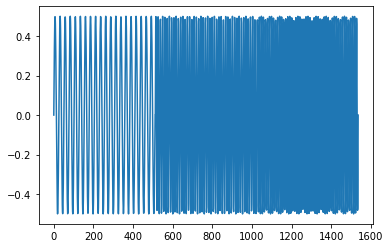

In [21]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# Generate a signal

samplerate = 512

# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq1 = 20
freq2 = 45
freq3 = 50

sineWave1 = 0.5*np.sin(2*np.pi*freq1*timeAxis)
sineWave2 = 0.5*np.sin(2*np.pi*freq2*timeAxis)
sineWave3 = 0.5*np.sin(2*np.pi*freq3*timeAxis)

sineFull = np.concatenate((sineWave1,sineWave2,sineWave3))

plt.plot(sineFull)

**Taking a block of the Concatenated Sine Wave**

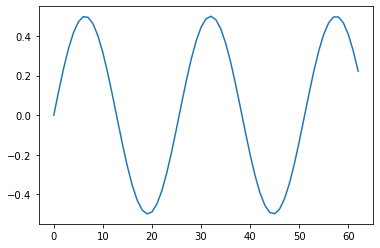

In [14]:
blockSize = 64

sineBlock = sineFull[0:blockSize-1]
plt.plot(sineBlock)

In [15]:
# This can be repeated 24 times with our given Full Wave, hopping at the blockSize
sineBlocks = np.zeros((24,(blockSize-1)))
for n in range(24):
    sineBlocks[n] = sineFull[n*blockSize:(n*blockSize + blockSize)-1]

### Window Functions with scipy.window

In [16]:
N = 64  # Window length

# Using a dictionary for multiple windows
windows = {
    'Rectangular': np.ones(N-1),
    'Hanning': signal.windows.hann(N-1),
    'Hamming': signal.windows.hamming(N-1),
    'Blackman': signal.windows.blackman(N-1),
    'Kaiser': signal.windows.kaiser(N-1, beta=8)
}


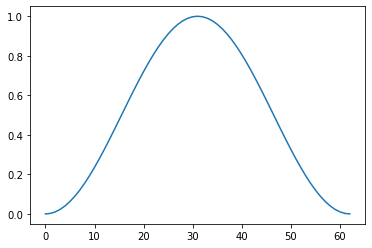

In [17]:
plt.plot(windows['Hanning'])

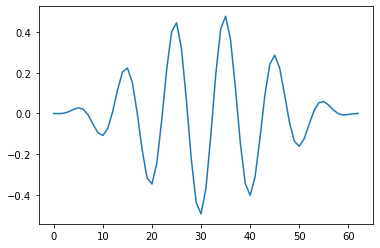

In [18]:
windowed_block = sineBlocks[23]*windows['Hanning']
plt.plot(sineBlocks[23]*windows['Hanning'])

/var/folders/td/wr0v_l5j16bgp1cvydp7pmqc0000gn/T/ipykernel_5319/365779943.py:22: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im = axes[1].pcolormesh(t, f, 10 * np.log10(Sxx))


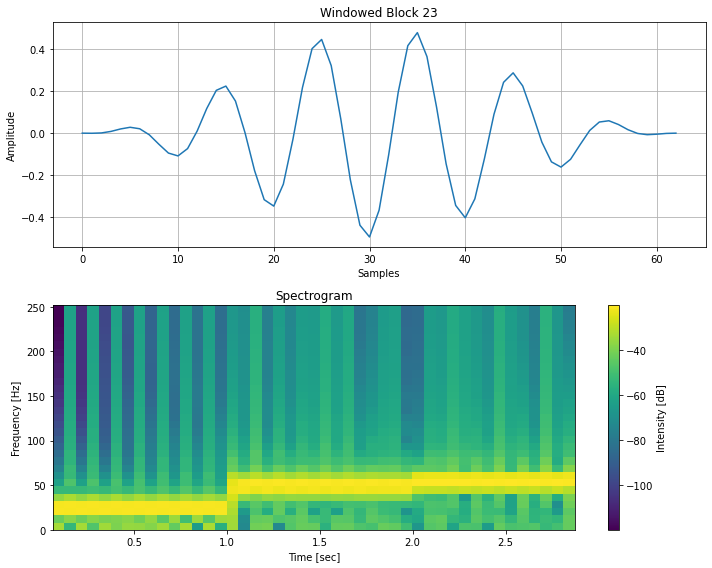

Spectrogram shape: (32, 46)
Frequency bins: 32
Time points: 46


In [22]:
# Create spectrogram
# For all blocks
f, t, Sxx = signal.spectrogram(
   sineBlocks.flatten(),  # Flatten all blocks into single array
   fs=512,              # Sampling frequency
   window='hann',
   nperseg=len(sineBlocks[23]),  # Window length same as block length
   noverlap=len(sineBlocks[23])//2  # 50% overlap
)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Time domain - windowed block
axes[0].plot(windowed_block)
axes[0].set_title('Windowed Block 23')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

# Spectrogram
im = axes[1].pcolormesh(t, f, 10 * np.log10(Sxx))
axes[1].set_title('Spectrogram')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_xlabel('Time [sec]')
fig.colorbar(im, ax=axes[1], label='Intensity [dB]')

plt.tight_layout()
plt.show()

# Print some properties
print(f"Spectrogram shape: {Sxx.shape}")
print(f"Frequency bins: {len(f)}")
print(f"Time points: {len(t)}")